# Power Lognormal Distribution

The **Power Lognormal distribution** generalises the Lognormal by adding a power parameter p. Its hazard function is p times the Lognormal hazard — making it more flexible for reliability modeling where the standard Lognormal hazard shape (first increasing then decreasing) doesn't fit.

| Property | Value |
|---|---|
| **Parameters** | p (power/shape, p > 0), σ (scale-shape), μ (location), B (scale) |
| **PDF** | f(x) = p · φ(z)/σx · [Φ(z)]^(p−1), where z = ln((x−μ)/B)/σ |
| **CDF** | F(x) = [Φ(z)]^p |
| **Hazard** | h(x) = p × (Lognormal hazard) |
| **Special case** | p=1 → Standard Lognormal |
| **Use cases** | Reliability analysis with non-standard hazard shapes |
| **Note** | Requires MLE numerical optimisation; not in standard libraries |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

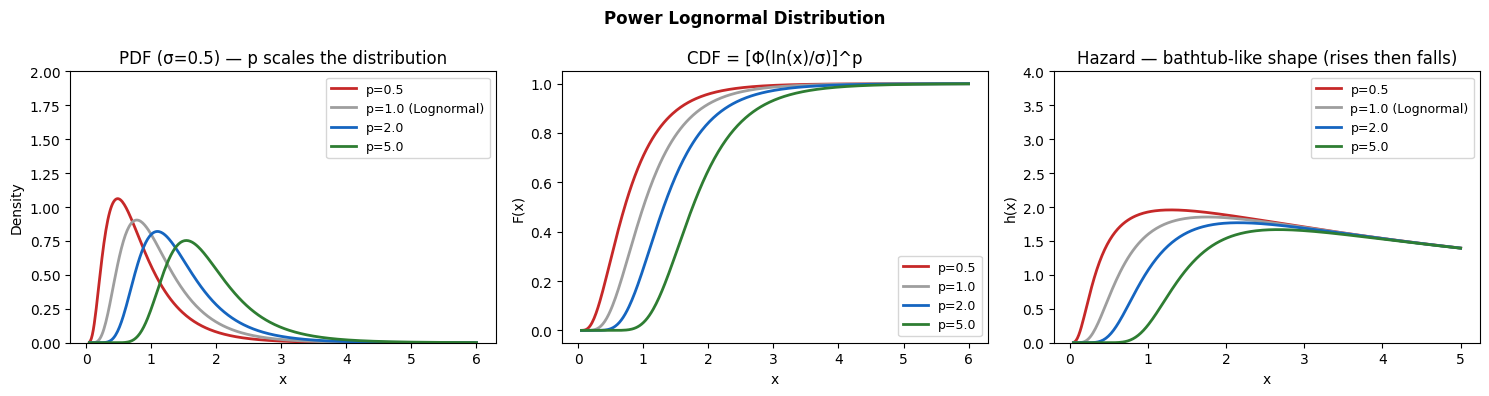

In [2]:
# Implement Power Lognormal manually (F(x) = Phi(z)^p, z=log(x)/sigma)
def power_lognormal_pdf(x, p, sigma, mu=0, B=1):
    z = (np.log((x - mu) / B)) / sigma
    phi = stats.norm.pdf(z)
    Phi = stats.norm.cdf(z)
    return p * phi / (sigma * (x - mu)) * Phi**(p-1)

def power_lognormal_cdf(x, p, sigma, mu=0, B=1):
    z = (np.log((x - mu) / B)) / sigma
    return stats.norm.cdf(z)**p

x = np.linspace(0.05, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Power Lognormal Distribution', fontsize=12, fontweight='bold')

sigma = 0.5

# PDF for varying p
for p, color, label in [(0.5, '#C62828', 'p=0.5'),
                         (1.0, '#9E9E9E', 'p=1.0 (Lognormal)'),
                         (2.0, '#1565C0', 'p=2.0'),
                         (5.0, '#2E7D32', 'p=5.0')]:
    y = power_lognormal_pdf(x, p=p, sigma=sigma)
    axes[0].plot(x, y, color=color, linewidth=2, label=label)
axes[0].set_title(f'PDF (σ={sigma}) — p scales the distribution')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2.0)
axes[0].legend(fontsize=9)

# CDF
for p, color, label in [(0.5, '#C62828', 'p=0.5'), (1.0, '#9E9E9E', 'p=1.0'),
                         (2.0, '#1565C0', 'p=2.0'), (5.0, '#2E7D32', 'p=5.0')]:
    axes[1].plot(x, power_lognormal_cdf(x, p=p, sigma=sigma),
                 color=color, linewidth=2, label=label)
axes[1].set_title('CDF = [Φ(ln(x)/σ)]^p')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=9)

# Hazard functions (p × Lognormal hazard)
x_h = np.linspace(0.05, 5, 300)
for p, color, label in [(0.5, '#C62828', 'p=0.5'), (1.0, '#9E9E9E', 'p=1.0 (Lognormal)'),
                         (2.0, '#1565C0', 'p=2.0'), (5.0, '#2E7D32', 'p=5.0')]:
    pdf_vals = power_lognormal_pdf(x_h, p=p, sigma=sigma)
    cdf_vals = power_lognormal_cdf(x_h, p=p, sigma=sigma)
    sf_vals = 1 - cdf_vals
    h = np.where(sf_vals > 1e-10, pdf_vals / sf_vals, 0)
    axes[2].plot(x_h, h, color=color, linewidth=2, label=label)
axes[2].set_title('Hazard — bathtub-like shape (rises then falls)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('h(x)')
axes[2].set_ylim(0, 4)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **p=1** | Reduces to standard Lognormal |
| **Hazard** | Non-monotone (rises then falls) — useful for mid-life failure patterns |
| **p scales hazard** | h_PowerLognormal(x) = p × h_Lognormal(x) |
| **Two shape params** | p and σ together control the distribution shape — more flexible than Lognormal |
| **vs Weibull** | Weibull has monotone hazard; Power Lognormal can model non-monotone |
| **Software** | Manual implementation required — not in scipy/statsmodels directly |